Idea: Disease Diagnosis from Symptoms

Team Members: Lana Ismail - 20210229, Amro Al Fawa’eer - 20201151

Dataset: https://www.kaggle.com/datasets/itachi9604/disease-symptom-description-dataset

In [41]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization, Input
from sklearn.metrics import classification_report, confusion_matrix
from keras.layers import BatchNormalization
from keras.regularizers import l2
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.optimizers import Adam

In [42]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
path = '/content/drive/MyDrive/ML_Project/dataset.csv'

df = pd.read_csv(path)

In [44]:
df

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,(vertigo) Paroymsal Positional Vertigo,vomiting,headache,nausea,spinning_movements,loss_of_balance,unsteadiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4916,Acne,skin_rash,pus_filled_pimples,blackheads,scurring,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4917,Urinary tract infection,burning_micturition,bladder_discomfort,foul_smell_of urine,continuous_feel_of_urine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4918,Psoriasis,skin_rash,joint_pain,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
df.shape

(4920, 18)

In [46]:
df.isna().sum()

,0
Disease,0
Symptom_1,0
Symptom_2,0
Symptom_3,0
Symptom_4,348
Symptom_5,1206
Symptom_6,1986
Symptom_7,2652
Symptom_8,2976
Symptom_9,3228


In [47]:
col_drop = ['Symptom_12', 'Symptom_13','Symptom_14','Symptom_15','Symptom_16','Symptom_17']
df = df.drop(columns=col_drop)

In [48]:
df

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
4915,(vertigo) Paroymsal Positional Vertigo,vomiting,headache,nausea,spinning_movements,loss_of_balance,unsteadiness,NaN,NaN,NaN,NaN,NaN
4916,Acne,skin_rash,pus_filled_pimples,blackheads,scurring,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4917,Urinary tract infection,burning_micturition,bladder_discomfort,foul_smell_of urine,continuous_feel_of_urine,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4918,Psoriasis,skin_rash,joint_pain,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,NaN,NaN,NaN,NaN,NaN


In [49]:
Disease = df['Disease'].unique()
Disease

array(['Fungal infection', 'Allergy', 'GERD', 'Chronic cholestasis',
       'Drug Reaction', 'Peptic ulcer diseae', 'AIDS', 'Diabetes ',
       'Gastroenteritis', 'Bronchial Asthma', 'Hypertension ', 'Migraine',
       'Cervical spondylosis', 'Paralysis (brain hemorrhage)', 'Jaundice',
       'Malaria', 'Chicken pox', 'Dengue', 'Typhoid', 'hepatitis A',
       'Hepatitis B', 'Hepatitis C', 'Hepatitis D', 'Hepatitis E',
       'Alcoholic hepatitis', 'Tuberculosis', 'Common Cold', 'Pneumonia',
       'Dimorphic hemmorhoids(piles)', 'Heart attack', 'Varicose veins',
       'Hypothyroidism', 'Hyperthyroidism', 'Hypoglycemia',
       'Osteoarthristis', 'Arthritis',
       '(vertigo) Paroymsal  Positional Vertigo', 'Acne',
       'Urinary tract infection', 'Psoriasis', 'Impetigo'], dtype=object)

In [50]:
len(Disease)

41

In [51]:
columns = df.columns[1:]
columns

Index(['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5',
       'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10',
       'Symptom_11'],
      dtype='object')

In [52]:
symptoms = pd.unique(df[columns].values.ravel())
symptoms

array(['itching', ' skin_rash', ' nodal_skin_eruptions',
       ' dischromic _patches', nan, ' continuous_sneezing', ' shivering',
       ' chills', ' watering_from_eyes', ' stomach_pain', ' acidity',
       ' ulcers_on_tongue', ' vomiting', ' cough', ' chest_pain',
       ' yellowish_skin', ' nausea', ' loss_of_appetite',
       ' abdominal_pain', ' yellowing_of_eyes', ' burning_micturition',
       ' spotting_ urination', ' passage_of_gases', ' internal_itching',
       ' indigestion', ' muscle_wasting', ' patches_in_throat',
       ' high_fever', ' extra_marital_contacts', ' fatigue',
       ' weight_loss', ' restlessness', ' lethargy',
       ' irregular_sugar_level', ' blurred_and_distorted_vision',
       ' obesity', ' excessive_hunger', ' increased_appetite',
       ' polyuria', ' sunken_eyes', ' dehydration', ' diarrhoea',
       ' breathlessness', ' family_history', ' mucoid_sputum',
       ' headache', ' dizziness', ' loss_of_balance',
       ' lack_of_concentration', ' stiff

In [53]:
len(symptoms)-1

126

In [54]:
label_encoder = LabelEncoder()
symp = label_encoder.fit_transform(symptoms)
symp

array([125,  95,  69,  30, 126,  23,  91,  18, 116, 101,   2, 112, 115,
        24,  17, 124,  67,  57,   0, 123,  16,  99,  76,  49,  47,  65,
        77,  43,  36,  39, 120,  88,  56,  50,  12,  70,  35,  46,  79,
       102,  27,  29,  13,  37,  63,  42,  32,  58,  55, 100,  28,  51,
       114,   6, 117,  68, 118,   4,  26, 103,  64,  60, 104,  59,  86,
        53,  71,  21, 111,   7, 122,  83,  84,  20,   3, 106,  31,  45,
        40,  78, 110,  87,  93,  38,  89,  72,  73,  11,  52,  25,  15,
       109, 107,  80, 119,  19,  61,  81,  34,  14, 108,  66,   1,   5,
        96,  75,  33,  54,  44, 105,  74,  62,  98, 113,  82,   8,  90,
         9,  41,  22,  94,  92,  97,  48,  10,  85, 121])

In [55]:
encodedSymp = dict(zip(symptoms, symp))
encodedSymp

{'itching': 125,
 ' skin_rash': 95,
 ' nodal_skin_eruptions': 69,
 ' dischromic _patches': 30,
 nan: 126,
 ' continuous_sneezing': 23,
 ' shivering': 91,
 ' chills': 18,
 ' watering_from_eyes': 116,
 ' stomach_pain': 101,
 ' acidity': 2,
 ' ulcers_on_tongue': 112,
 ' vomiting': 115,
 ' cough': 24,
 ' chest_pain': 17,
 ' yellowish_skin': 124,
 ' nausea': 67,
 ' loss_of_appetite': 57,
 ' abdominal_pain': 0,
 ' yellowing_of_eyes': 123,
 ' burning_micturition': 16,
 ' spotting_ urination': 99,
 ' passage_of_gases': 76,
 ' internal_itching': 49,
 ' indigestion': 47,
 ' muscle_wasting': 65,
 ' patches_in_throat': 77,
 ' high_fever': 43,
 ' extra_marital_contacts': 36,
 ' fatigue': 39,
 ' weight_loss': 120,
 ' restlessness': 88,
 ' lethargy': 56,
 ' irregular_sugar_level': 50,
 ' blurred_and_distorted_vision': 12,
 ' obesity': 70,
 ' excessive_hunger': 35,
 ' increased_appetite': 46,
 ' polyuria': 79,
 ' sunken_eyes': 102,
 ' dehydration': 27,
 ' diarrhoea': 29,
 ' breathlessness': 13,
 ' fam

In [56]:
for col in columns:
    df[col] = df[col].map(encodedSymp)

In [57]:
df

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11
0,Fungal infection,125,95,69,30,126,126,126,126,126,126,126
1,Fungal infection,95,69,30,126,126,126,126,126,126,126,126
2,Fungal infection,125,69,30,126,126,126,126,126,126,126,126
3,Fungal infection,125,95,30,126,126,126,126,126,126,126,126
4,Fungal infection,125,95,69,126,126,126,126,126,126,126,126
...,...,...,...,...,...,...,...,...,...,...,...,...
4915,(vertigo) Paroymsal Positional Vertigo,115,42,67,98,58,113,126,126,126,126,126
4916,Acne,95,82,8,90,126,126,126,126,126,126,126
4917,Urinary tract infection,16,9,41,22,126,126,126,126,126,126,126
4918,Psoriasis,95,53,94,92,97,48,126,126,126,126,126


In [58]:
df['Disease'] = label_encoder.fit_transform(df['Disease'])

In [59]:
df

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11
0,15,125,95,69,30,126,126,126,126,126,126,126
1,15,95,69,30,126,126,126,126,126,126,126,126
2,15,125,69,30,126,126,126,126,126,126,126,126
3,15,125,95,30,126,126,126,126,126,126,126,126
4,15,125,95,69,126,126,126,126,126,126,126,126
...,...,...,...,...,...,...,...,...,...,...,...,...
4915,0,115,42,67,98,58,113,126,126,126,126,126
4916,2,95,82,8,90,126,126,126,126,126,126,126
4917,38,16,9,41,22,126,126,126,126,126,126,126
4918,35,95,53,94,92,97,48,126,126,126,126,126


In [60]:
X = df.drop('Disease', axis=1)
y = df['Disease']

In [61]:
y

,Disease
0,15
1,15
2,15
3,15
4,15
...,...
4915,0
4916,2
4917,38
4918,35


In [62]:
class_counts = y.value_counts()
print(class_counts)

Disease
15    120
20    120
22    120
3     120
36    120
10    120
34    120
13    120
18    120
39    120
26    120
24    120
25    120
31    120
5     120
0     120
2     120
38    120
35    120
21    120
19    120
4     120
40    120
16    120
9     120
14    120
33    120
1     120
12    120
17    120
6     120
23    120
30    120
7     120
32    120
28    120
29    120
8     120
11    120
37    120
27    120
Name: count, dtype: int64


In [63]:
y = to_categorical(y, num_classes=len(df['Disease'].unique()))

In [64]:
y.shape

(4920, 41)

In [65]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [66]:
X_train

,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11
682,18,39,24,43,13,103,59,78,17,38,89
3963,18,39,24,43,13,103,59,78,17,38,89
3126,42,17,32,58,55,126,126,126,126,126,126
4480,2,47,42,12,35,100,28,51,114,126,126
3411,115,102,27,29,126,126,126,126,126,126,126
...,...,...,...,...,...,...,...,...,...,...,...
4426,95,53,94,92,97,48,126,126,126,126,126
466,115,47,57,0,49,126,126,126,126,126,126
3092,95,18,53,115,39,43,42,67,57,71,6
3772,125,95,69,30,126,126,126,126,126,126,126


In [67]:
X_test

,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11
4094,66,100,105,62,74,126,126,126,126,126,126
3824,2,47,42,12,35,100,28,51,114,126,126
330,115,39,5,103,42,67,12,35,96,51,75
2117,77,43,36,126,126,126,126,126,126,126,126
999,95,18,53,115,39,42,67,57,71,6,59
...,...,...,...,...,...,...,...,...,...,...,...
1777,42,118,4,126,126,126,126,126,126,126,126
4523,115,42,118,4,126,126,126,126,126,126,126
3801,115,13,103,17,126,126,126,126,126,126,126
4347,23,91,18,116,126,126,126,126,126,126,126


In [68]:
y_test.shape

(738, 41)

In [69]:
y_train.shape

(3444, 41)

In [70]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.02)))
model.add(BatchNormalization())

model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.02)))
model.add(BatchNormalization())

model.add(Dense(y_train.shape[1], activation='softmax'))

optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [71]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [72]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 41)                  │           1,353 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,585 (17.91 KB)

 Trainable params: 4,393 (17.16 KB)

 Non-trainable params: 192 (768.00 B)

In [73]:
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_val, y_val), callbacks=[early_stopping])

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.0910 - loss: 5.0411 - val_accuracy: 0.0732 - val_loss: 4.8666
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2709 - loss: 4.0428 - val_accuracy: 0.3184 - val_loss: 3.8132
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5242 - loss: 3.3738 - val_accuracy: 0.5569 - val_loss: 3.1813
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6454 - loss: 2.8685 - val_accuracy: 0.6870 - val_loss: 2.6945
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7323 - loss: 2.4330 - val_accuracy: 0.7534 - val_loss: 2.3504
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7770 - loss: 2.1212 - val_accuracy: 0.7696 - val_loss: 2.0745
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8023 - loss: 1.8598 - val_accuracy: 0.8198 - val_loss: 1.8404
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8342 - loss: 1.6383 - val_accuracy: 0.8455 - val_loss:

In [74]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9766 - loss: 0.2150 
Test loss: 0.22477352619171143
Test accuracy: 0.9701896905899048


In [75]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes))

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       0.86      1.00      0.93        19
           2       0.68      1.00      0.81        19
           3       1.00      1.00      1.00        14
           4       0.90      1.00      0.95        18
           5       1.00      1.00      1.00        23
           6       1.00      1.00      1.00        24
           7       1.00      1.00      1.00        11
           8       1.00      1.00      1.00        23
           9       1.00      1.00      1.00        14
          10       1.00      1.00      1.00        18
          11       1.00      1.00      1.00        17
          12       1.00      1.00      1.00        12
          13       1.00      0.92      0.96        25
          14       1.00      1.00      1.00        18
          15       1.00      0.69      0.81        16
          16       1.00      1.00      1.0

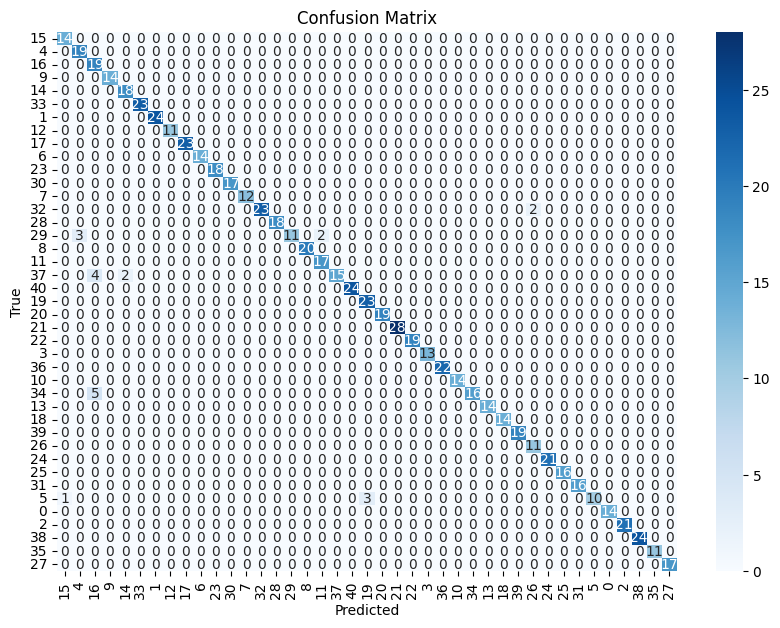

In [76]:
conf_matrix = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=df['Disease'].unique(), yticklabels=df['Disease'].unique())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

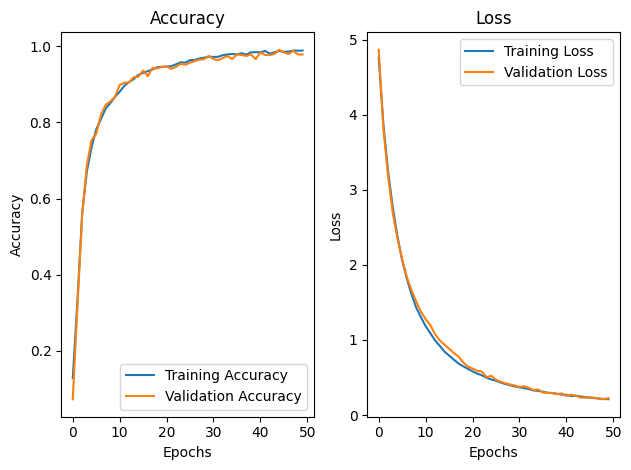

In [77]:
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()